# Tomorrow's 24 prices: forecasting the Polish day-ahead price

**Cenergia — Notebook 03: forecasting**

Notebooks 01 and 02 established what the day-ahead price series looks like and
why it moves. This notebook asks the operational question: can tomorrow's 24
hourly prices be forecast *before the auction that sets them clears*, and how
well?

**This notebook explains a result that already exists — it does not re-run
the model.** The forecaster is a LightGBM regressor evaluated with a 6-month
walk-forward backtest (monthly refit, strict train-before-test split); that
run is reproducible with `make backtest` but takes several minutes end to
end, so everything below reads the three artifacts it already produced and
committed to the repo:

- `results/backtest.csv` — MAE/RMSE/rMAE per model x month (+ an `ALL` row)
- `results/backtest_per_hour.csv` — MAE per model x hour-of-day
- `results/predictions.parquet` — every hourly prediction (`y`, `naive`,
  `seasonal_naive`, `lgbm`) across the 6 test months

No number below is hand-typed: every statistic and chart is computed live
from these three files (or, where noted, from the same feature-matrix
function the model itself trains on).


## Setup

Same imports, palette, and plot theme as notebooks 01-02 (reused as-is, so a
color means the same thing in every notebook), plus the modeling interfaces
this notebook reads rather than recomputes: `FEATURES` and `BREAK_TS_UTC`
from `cenergia.features.matrix`, and the three committed result files above.


In [1]:
import warnings

import duckdb
import holidays
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from cenergia import analysis, paths
from cenergia.features import matrix as matrix_module
from cenergia.features.matrix import BREAK_TS_UTC, FEATURES, build_matrix
from cenergia.models import metrics as metrics_module

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.float_format", lambda x: f"{x:,.1f}")

# Muted, colorblind-checked categorical palette (fixed hue order, reused as-is
# from notebooks 01-02 so a color means the same thing in every notebook).
BLUE, AQUA, AMBER, GREEN, VIOLET, RED, MAGENTA, ORANGE = (
    "#2a78d6",
    "#1baf7a",
    "#eda100",
    "#008300",
    "#4a3aa7",
    "#d03b3b",
    "#e87ba4",
    "#eb6834",
)
INK = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRID = "#e1e0d9"
BASELINE = "#c3c2b7"

sns.set_theme(
    style="white",
    rc={
        "axes.edgecolor": BASELINE,
        "axes.labelcolor": INK_SECONDARY,
        "text.color": INK,
        "xtick.color": INK_MUTED,
        "ytick.color": INK_MUTED,
        "grid.color": GRID,
        "font.family": "sans-serif",
        "figure.facecolor": "white",
        "axes.facecolor": "white",
    },
)
FIGSIZE_WIDE = (11, 4.5)

# One color per model, reused across every chart in this notebook.
MODEL_COLOR = {"naive": INK_MUTED, "seasonal_naive": AMBER, "lgbm": BLUE}

In [2]:
backtest = pd.read_csv(paths.RESULTS / "backtest.csv")
per_hour = pd.read_csv(paths.RESULTS / "backtest_per_hour.csv")
predictions = pd.read_parquet(paths.RESULTS / "predictions.parquet")

print(
    f"backtest.csv: {len(backtest)} rows "
    f"({backtest['model'].nunique()} models x {backtest['month'].nunique()} month/ALL groups)"
)
print(
    f"predictions.parquet: {len(predictions):,} hourly rows, "
    f"{predictions.index.min()} to {predictions.index.max()}"
)
print(f"test months: {sorted(m for m in predictions['month'].unique())}")

backtest.csv: 21 rows (3 models x 7 month/ALL groups)
predictions.parquet: 4,343 hourly rows, 2025-12-31 23:00:00 to 2026-06-30 21:00:00
test months: ['2026-01', '2026-02', '2026-03', '2026-04', '2026-05', '2026-06']


## 1. The problem, honestly framed

Poland's day-ahead market clears once per auction day **D**, for delivery on
**D+1**. Every participant's bids — and, for a forecaster, every model
input — must be final before a fixed cutoff on day D; the auction then
clears and publishes all 24 hourly prices for D+1 at once. A forecast made
after that cutoff isn't a forecast, it's hindsight.


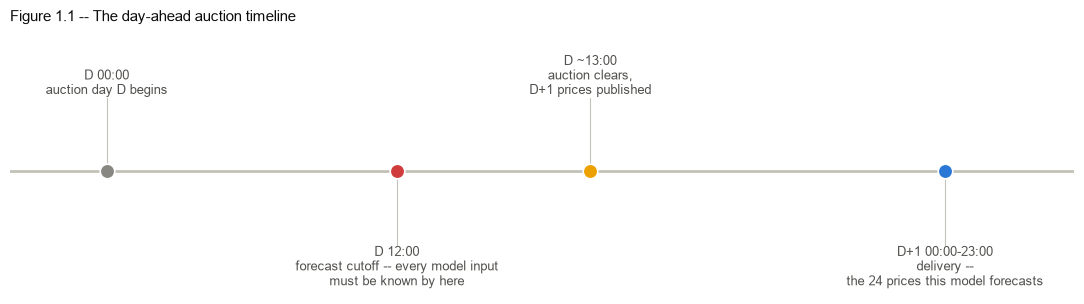

In [3]:
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.axhline(0.5, color=BASELINE, lw=2, zorder=1)

events = [
    (0.1, "D 00:00", "auction day D begins", INK_MUTED),
    (1.0, "D 12:00", "forecast cutoff -- every model input\nmust be known by here", RED),
    (1.6, "D ~13:00", "auction clears,\nD+1 prices published", AMBER),
    (2.7, "D+1 00:00-23:00", "delivery --\nthe 24 prices this model forecasts", BLUE),
]
for i, (x, tlabel, desc, color) in enumerate(events):
    ax.scatter([x], [0.5], s=110, color=color, zorder=3, edgecolor="white", linewidth=1.2)
    y_text = 0.80 if i % 2 == 0 else 0.20
    va = "bottom" if i % 2 == 0 else "top"
    ax.annotate(
        f"{tlabel}\n{desc}",
        xy=(x, 0.5),
        xytext=(x, y_text),
        ha="center",
        va=va,
        fontsize=9,
        color=INK_SECONDARY,
    )
    ax.plot([x, x], [0.5, y_text], color=BASELINE, lw=0.8, zorder=2)

ax.set_xlim(-0.2, 3.1)
ax.set_ylim(0, 1)
ax.axis("off")
ax.set_title("Figure 1.1 -- The day-ahead auction timeline", loc="left", fontsize=11, pad=20)
plt.tight_layout()
plt.show()

Everything the model uses as input has to be known **before that D 12:00
cutoff** — not just "before delivery," which would be a softer, leakier bar.
`matrix.py`'s module docstring derives exactly which lags clear that bar;
quoted verbatim below by printing the module's live `__doc__`, so this
notebook can never drift from what the code actually enforces.


In [4]:
print(matrix_module.__doc__)

Leakage-safe feature matrix.

Cutoff-safety derivation: a D+1 forecast is made before 12:00 Europe/Warsaw on
day D. Day-ahead prices for delivery day X are published ~13:00 on day X-1, so
at the forecast moment every price with local delivery date <= D is known. A
price lag of `L` hours from delivery hour `h` (local) of day D+1 reaches local
day <= D iff `L >= h + 1`; the worst case is `h = 23`, so any `L >= 24` is safe
for all hours. `load_fcst_mw` (PSE's D+1 forecast) and weather (Open-Meteo D+1
forecast) are forecast-kind: published before the cutoff by construction.
Calendar features are deterministic.



The rule in one line: any price *lag* of 24 hours or more clears the cutoff
for every hour of the delivery day (the worst case is hour 23, which needs
`lag >= 23 + 1 = 24`). That's why `FEATURES` only uses `price_lag24`,
`price_lag48`, `price_lag168`, and the two rolling stats built on top of
`price_lag24` — never anything shorter. `load_fcst_mw` and the weather
columns are *forecast-kind*: PSE's own D+1 load forecast and Open-Meteo's
D+1 weather forecast are, by construction, published before the cutoff
rather than derived from it. Calendar features (`hour_local`, `dow_local`,
...) are deterministic and need no cutoff at all.


### Why MAPE is excluded

`cenergia.models.metrics` computes MAE, RMSE, and rMAE — deliberately no
MAPE. The reason is in the module's own docstring, quoted live below.


In [5]:
print(metrics_module.__doc__)

neg_hours = int((predictions["y"] < 0).sum())
print(
    f"\nIn the 6-month backtest window itself: {neg_hours} of {len(predictions):,} hours "
    f"({neg_hours / len(predictions) * 100:.1f}%) have a negative price."
)

MAE/RMSE/rMAE. No MAPE: Polish day-ahead prices cross zero (negative-price hours),
which makes percentage errors explode or flip sign — rMAE vs naive is the skill metric.

In the 6-month backtest window itself: 224 of 4,343 hours (5.2%) have a negative price.


Percentage error is undefined at a zero price and flips sign or explodes
near one — and negative prices aren't a tail curiosity here, they're over 5%
of the very window this backtest evaluates. rMAE (this model's MAE divided
by naive's MAE on the same rows) is used instead: it's a *skill* score —
under 1 means "beats yesterday's same-hour price," over 1 means "loses to
it" — and it stays well-behaved on both sides of zero because it never
divides by the price itself.


## 2. Features

`FEATURES` (`cenergia.features.matrix`) is the exact, ordered column list the
model trains and predicts on. One line of rationale per feature below; the
`assert` ties this table to the live list so it can't silently drift from
what the model actually uses.


In [6]:
FEATURE_RATIONALE = {
    "price_lag24": "yesterday, same hour -- strongest predictor, and the naive baseline itself.",
    "price_lag48": "two days back, same hour -- a second short-run anchor beyond lag24.",
    "price_lag168": "one week back, same hour -- weekly anchor and the seasonal-naive baseline.",
    "price_roll7d_mean": "7-day rolling mean, window at lag24 -- the current price regime's level.",
    "price_roll7d_std": "7-day rolling std, window at lag24 -- how volatile the current regime is.",
    "load_fcst_mw": "PSE's own D+1 load forecast -- demand side of the merit-order effect (NB 02).",
    "temp_c": "D+1 forecast temperature -- drives heating/cooling demand.",
    "wind_ms": "D+1 forecast wind speed -- physical driver of wind output (Notebook 02: r=0.90).",
    "ghi_wm2": "D+1 forecast irradiance -- physical driver of solar output (Notebook 02: r=0.92).",
    "cloud_pct": "D+1 forecast cloud cover -- a second, independent read on solar output.",
    "hour_local": "hour of day (Europe/Warsaw) -- the dominant daily price shape.",
    "dow_local": "day of week (Europe/Warsaw) -- weekday/weekend demand pattern.",
    "month_local": "calendar month -- seasonal demand and renewables mix.",
    "is_holiday": "Polish public holiday flag -- holidays shift load like a weekend without one.",
    "is_weekend": "Saturday/Sunday flag -- the low-demand, low-price regime.",
    "post_break": "1 from BREAK_TS_UTC onward -- flags the hourly-to-15-minute settlement switch.",
}
assert set(FEATURE_RATIONALE) == set(FEATURES), "rationale table drifted from FEATURES"

features_df = pd.DataFrame({"feature": FEATURES})
features_df["rationale"] = features_df["feature"].map(FEATURE_RATIONALE)
features_df

,feature,rationale
0,price_lag24,"yesterday, same hour -- strongest predictor, a..."
1,price_lag48,"two days back, same hour -- a second short-run..."
2,price_lag168,"one week back, same hour -- weekly anchor and ..."
3,price_roll7d_mean,"7-day rolling mean, window at lag24 -- the cur..."
4,price_roll7d_std,"7-day rolling std, window at lag24 -- how vola..."
5,load_fcst_mw,PSE's own D+1 load forecast -- demand side of ...
6,temp_c,D+1 forecast temperature -- drives heating/coo...
7,wind_ms,D+1 forecast wind speed -- physical driver of ...
8,ghi_wm2,D+1 forecast irradiance -- physical driver of ...
9,cloud_pct,"D+1 forecast cloud cover -- a second, independ..."


The leakage guard (`tests/unit/features/test_leakage.py`) is what actually
*enforces* the availability rule above, rather than just documenting it —
every feature must be classified into one of three kinds (`lagged_price`,
`forecast`, `deterministic`), and every `lagged_price` feature's lag must
independently satisfy `lag_is_cutoff_safe`. Quoted verbatim below by reading
the file straight off disk, not retyped.


In [7]:
leakage_test_path = paths.ROOT / "tests" / "unit" / "features" / "test_leakage.py"
print(leakage_test_path.read_text())

"""THE leakage guard: every feature must be classified and provably pre-cutoff."""

from cenergia.features import matrix


def test_every_feature_is_classified() -> None:
    assert set(matrix.FEATURE_KIND) == set(matrix.FEATURES)


def test_lagged_price_features_are_cutoff_safe() -> None:
    for name, (kind, lag) in matrix.FEATURE_KIND.items():
        if kind == "lagged_price":
            assert lag is not None and matrix.lag_is_cutoff_safe(lag), name
        else:
            assert kind in ("forecast", "deterministic"), name


def test_unsafe_lag_rejected() -> None:
    # h=23 delivery hour would see a 12h lag reach into its own delivery day
    assert not matrix.lag_is_cutoff_safe(12)
    assert not matrix.lag_is_cutoff_safe(23)
    assert matrix.lag_is_cutoff_safe(24)



`test_every_feature_is_classified` is a completeness check: nothing in
`FEATURES` can slip through unclassified. `test_lagged_price_features_are_cutoff_safe`
is the actual leakage guard — every `lagged_price` feature must carry a lag
that clears the >=24h bar, and every other feature must be explicitly
declared `forecast` or `deterministic` rather than silently assumed safe.
`test_unsafe_lag_rejected` pins the boundary itself: lag 23 (which would
reach into the delivery day's own hour 23) is rejected, lag 24 is accepted —
so the cutoff is asserted in CI, not just written down in a comment.


## 3. Results

Summary metrics from the committed 6-month walk-forward backtest
(`results/backtest.csv`): three models (`naive` = `price_lag24`,
`seasonal_naive` = `price_lag168`, `lgbm`), six test months, monthly refit
with a strict train-strictly-before-test-month split. `rmae < 1` (highlighted)
means the model beats the naive baseline on that slice.


In [8]:
def _highlight_skill(val: float) -> str:
    return "background-color: #d9ede3; font-weight: 600" if val < 1.0 else ""


summary_display = backtest.copy()
summary_display["month"] = pd.Categorical(
    summary_display["month"],
    categories=["2026-01", "2026-02", "2026-03", "2026-04", "2026-05", "2026-06", "ALL"],
    ordered=True,
)
summary_display = summary_display.sort_values(["model", "month"])

styled_summary = (
    summary_display.style.format({"mae": "{:,.1f}", "rmse": "{:,.1f}", "rmae": "{:.3f}"})
    .map(_highlight_skill, subset=["rmae"])
    .hide(axis="index")
)
styled_summary

model,month,mae,rmse,rmae
lgbm,2026-01,100.5,183.0,0.557
lgbm,2026-02,95.2,128.7,1.328
lgbm,2026-03,87.7,118.3,0.680
lgbm,2026-04,99.7,163.8,0.721
lgbm,2026-05,87.1,147.4,0.787
lgbm,2026-06,87.4,144.6,0.640
lgbm,ALL,92.9,149.4,0.722
naive,2026-01,180.6,304.3,1.000
naive,2026-02,71.7,104.1,1.000
naive,2026-03,128.9,174.9,1.000


`lgbm` beats naive (`rmae < 1`) in 5 of the 6 test months, and on the full
`ALL` row (rmae=0.722): a genuine ~28% MAE reduction against a same-hour-
yesterday guess. `seasonal_naive` (last week, same hour) never beats plain
`naive` in any month — the most recent price level is a better predictor
than last week's, despite carrying the weekly seasonal pattern naive
lacks. The one lgbm exception is 2026-02 (rmae=1.328); Section 4 digs into
why that's a naive-baseline artifact, not an lgbm regression.


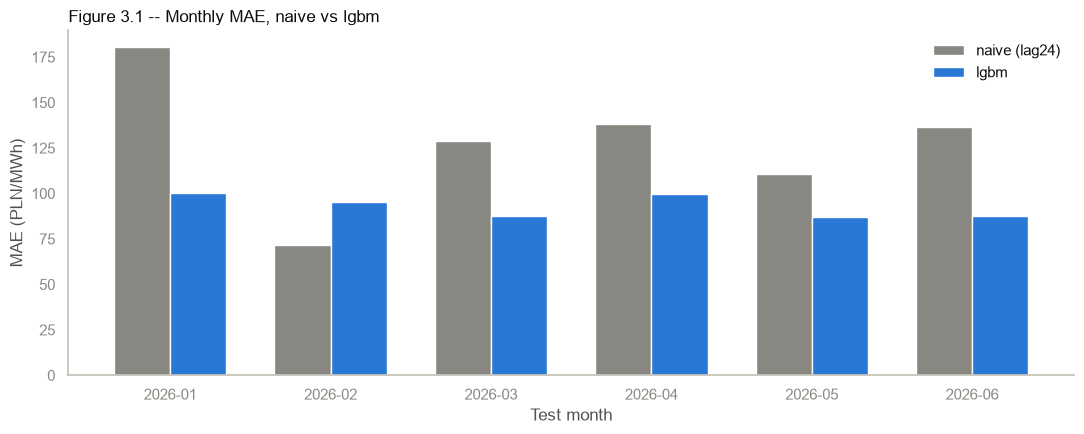

In [9]:
months_order = ["2026-01", "2026-02", "2026-03", "2026-04", "2026-05", "2026-06"]
bar_df = backtest[backtest["model"].isin(["naive", "lgbm"]) & backtest["month"].isin(months_order)]
bar_pivot = bar_df.pivot(index="month", columns="model", values="mae").reindex(months_order)

fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
x = range(len(bar_pivot))
width = 0.35
ax.bar(
    [i - width / 2 for i in x],
    bar_pivot["naive"],
    width,
    label="naive (lag24)",
    color=MODEL_COLOR["naive"],
)
ax.bar(
    [i + width / 2 for i in x],
    bar_pivot["lgbm"],
    width,
    label="lgbm",
    color=MODEL_COLOR["lgbm"],
)
ax.set_xticks(list(x))
ax.set_xticklabels(bar_pivot.index)
ax.set_ylabel("MAE (PLN/MWh)")
ax.set_xlabel("Test month")
ax.set_title("Figure 3.1 -- Monthly MAE, naive vs lgbm", loc="left")
ax.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

lgbm's monthly MAE is nearly flat (87-101 PLN/MWh across all 6 months) while
naive's swings widely (72-181 PLN/MWh) — lgbm is not just more accurate on
average, it's far more *consistent* month to month. Feb-2026 is the one
month naive happens to be easy (its MAE craters) while lgbm's MAE sits right
in its usual band; that gap between a flat numerator and a swinging
denominator is exactly what produces the rmae>1 anomaly in the table above.


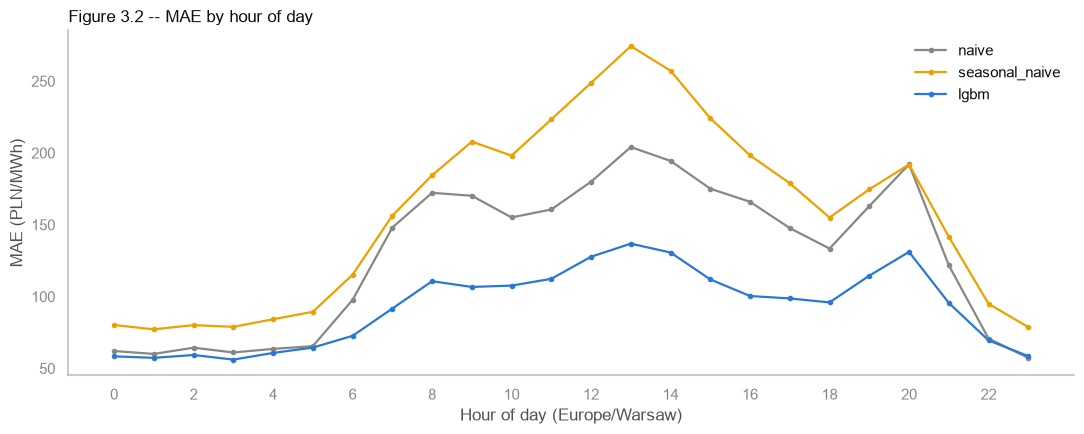

In [10]:
hour_pivot = per_hour.pivot(index="hour_local", columns="model", values="mae").sort_index()

fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
for model_name in ["naive", "seasonal_naive", "lgbm"]:
    ax.plot(
        hour_pivot.index,
        hour_pivot[model_name],
        marker="o",
        ms=3,
        lw=1.6,
        color=MODEL_COLOR[model_name],
        label=model_name,
    )
ax.set_xticks(range(0, 24, 2))
ax.set_xlabel("Hour of day (Europe/Warsaw)")
ax.set_ylabel("MAE (PLN/MWh)")
ax.set_title("Figure 3.2 -- MAE by hour of day", loc="left")
ax.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

In [11]:
lgbm_by_hour = hour_pivot["lgbm"].sort_values(ascending=False)
print("Hardest hours for lgbm (highest MAE):")
print(lgbm_by_hour.head(5))
print()
print("Easiest hours for lgbm (lowest MAE):")
print(lgbm_by_hour.tail(5))

Hardest hours for lgbm (highest MAE):
hour_local
13   136.8
20   131.1
14   130.7
12   127.7
19   114.5
Name: lgbm, dtype: float64

Easiest hours for lgbm (lowest MAE):
hour_local
2    59.3
23   58.5
0    58.4
1    57.3
3    56.1
Name: lgbm, dtype: float64


Every model's error has the same shape: flat and low overnight (hours 0-5,
22-23, lgbm MAE 56-70 PLN/MWh) and much higher through the day, with two
local peaks rather than one — midday (12-14h, lgbm MAE 128-137) and evening
(19-20h, lgbm MAE 115-131). Overnight demand is low, stable, and almost
entirely thermal, so tomorrow looks like yesterday. The two daytime peaks
are the mirror image of each other: **midday** is when solar output (and its
forecast error) is largest, so the depth of the trough is the least certain;
the **evening ramp** — solar falling off from ~16-19h local while demand
stays high into the evening peak — forces the merit order to swing hard from
cheap renewables to expensive marginal plant in a couple of hours, exactly
the kind of fast transition a day-ahead model has the hardest time timing
precisely. Both peaks are worse for every model, but lgbm's peak is
consistently the smallest of the three — it narrows the daytime gap without
eliminating it.


## 4. Error anatomy

Aggregate metrics hide where the model actually struggles. This section
looks at the worst individual days in `results/predictions.parquet`.


In [12]:
daily_errors = (
    predictions.assign(date=predictions.index.date)
    .groupby("date")
    .apply(
        lambda g: pd.Series(
            {
                "lgbm_mae": (g["y"] - g["lgbm"]).abs().mean(),
                "naive_mae": (g["y"] - g["naive"]).abs().mean(),
                "seasonal_naive_mae": (g["y"] - g["seasonal_naive"]).abs().mean(),
                "y_min": g["y"].min(),
                "y_max": g["y"].max(),
                "month": g["month"].iloc[0],
            }
        )
    )
)
worst5 = daily_errors.sort_values("lgbm_mae", ascending=False).head(5)

pl_holidays = holidays.country_holidays("PL")
worst5_display = worst5.copy()
worst5_display.insert(0, "weekday", [pd.Timestamp(d).day_name() for d in worst5_display.index])
worst5_display.insert(1, "pl_holiday", [bool(d in pl_holidays) for d in worst5_display.index])

worst5_display.style.format(
    {
        "lgbm_mae": "{:,.1f}",
        "naive_mae": "{:,.1f}",
        "seasonal_naive_mae": "{:,.1f}",
        "y_min": "{:,.1f}",
        "y_max": "{:,.1f}",
    }
)

,weekday,pl_holiday,lgbm_mae,naive_mae,seasonal_naive_mae,y_min,y_max,month
date,,,,,,,,
2026-01-12,Monday,False,461.9,683.8,492.9,380.8,"2,157.6",2026-01
2026-01-13,Tuesday,False,357.2,273.7,572.9,431.6,"2,104.9",2026-01
2026-04-26,Sunday,False,300.0,235.9,416.1,"-1,679.3",658.4,2026-04
2026-05-01,Friday,True,275.7,326.0,392.4,"-1,998.4",748.4,2026-05
2026-04-05,Sunday,True,242.2,290.2,454.3,-847.2,393.1,2026-04


The worst 5 days split cleanly into two distinct failure modes, not five
unrelated bad days. The worst 2 (2026-01-12, 2026-01-13, both ordinary
weekdays) are an **upward spike**: `y_max` above 2,100 PLN/MWh. The next 3
(2026-04-05 Easter Sunday, 2026-04-26 an ordinary Sunday, 2026-05-01 Labour
Day) are the mirror image — a **downward plunge**, `y_min` down to
-1,998 PLN/MWh — and every one of them is a Sunday or a national holiday.
That's not a coincidence explored further below.


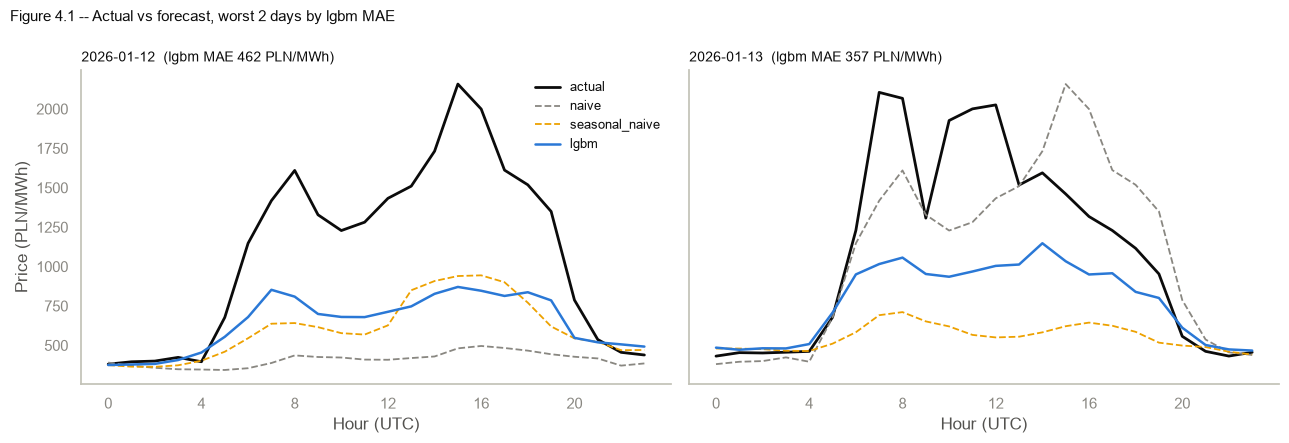

In [13]:
worst2_days = worst5.index[:2]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, day in zip(axes, worst2_days, strict=True):
    day_df = predictions.loc[str(day)]
    day_mae = worst5.loc[day, "lgbm_mae"]
    ax.plot(day_df.index.hour, day_df["y"], color=INK, lw=2, label="actual")
    ax.plot(
        day_df.index.hour,
        day_df["naive"],
        color=MODEL_COLOR["naive"],
        lw=1.3,
        ls="--",
        label="naive",
    )
    ax.plot(
        day_df.index.hour,
        day_df["seasonal_naive"],
        color=MODEL_COLOR["seasonal_naive"],
        lw=1.3,
        ls="--",
        label="seasonal_naive",
    )
    ax.plot(day_df.index.hour, day_df["lgbm"], color=MODEL_COLOR["lgbm"], lw=1.8, label="lgbm")
    ax.set_title(f"{day}  (lgbm MAE {day_mae:,.0f} PLN/MWh)", loc="left", fontsize=10)
    ax.set_xlabel("Hour (UTC)")
    ax.set_xticks(range(0, 24, 4))
axes[0].set_ylabel("Price (PLN/MWh)")
axes[0].legend(frameon=False, fontsize=9)
sns.despine()
fig.suptitle(
    "Figure 4.1 -- Actual vs forecast, worst 2 days by lgbm MAE",
    x=0.01,
    ha="left",
    fontsize=11,
)
plt.tight_layout()
plt.show()

In [14]:
for day in worst2_days:
    day_df = predictions.loc[str(day)]
    actual_peak = day_df["y"].max()
    lgbm_peak = day_df["lgbm"].max()
    print(
        f"{day}: actual peak {actual_peak:,.0f} PLN/MWh, lgbm's own peak {lgbm_peak:,.0f} PLN/MWh "
        f"(undershoot {actual_peak - lgbm_peak:,.0f} PLN/MWh)"
    )

2026-01-12: actual peak 2,158 PLN/MWh, lgbm's own peak 871 PLN/MWh (undershoot 1,287 PLN/MWh)
2026-01-13: actual peak 2,105 PLN/MWh, lgbm's own peak 1,148 PLN/MWh (undershoot 957 PLN/MWh)


lgbm tracks the *shape* of both days far better than either baseline — it
sees the ramp coming and peaks close to when the actual price peaks — but
systematically undershoots the *magnitude*, missing that day's own peak by
roughly 960-1,290 PLN/MWh. Naive is worse on day 1 (it's still forecasting
off a calm previous day) but recovers some ground on day 2, since by then
`price_lag24` already reflects yesterday's elevated price.


In [15]:
drivers = analysis.drivers_frame()
drivers["ts_utc"] = pd.to_datetime(drivers["ts_utc"])
drivers = drivers.set_index("ts_utc")

spike_window = drivers.loc["2026-01-12":"2026-01-13"]
overnight_wind = spike_window["wind_mw"].iloc[0]
midday_wind = spike_window.loc["2026-01-12 08:00":"2026-01-12 12:00", "wind_mw"].min()
peak_load_ts = spike_window["load_mw"].idxmax()

temp_lo, temp_hi = spike_window["temp_c"].min(), spike_window["temp_c"].max()
print(f"temp_c range across both days: {temp_lo:.1f} to {temp_hi:.1f} C")
print(
    f"load_mw peak: {spike_window['load_mw'].max():,.0f} MW at {peak_load_ts} "
    f"(load_fcst_mw same hour: {spike_window.loc[peak_load_ts, 'load_fcst_mw']:,.0f} MW)"
)
print(f"wind_mw: overnight ~{overnight_wind:,.0f} MW -> midday low ~{midday_wind:,.0f} MW")

temp_c range across both days: -6.0 to -3.0 C
load_mw peak: 27,345 MW at 2026-01-13 11:00:00 (load_fcst_mw same hour: 26,550 MW)
wind_mw: overnight ~4,146 MW -> midday low ~618 MW


The features had real signal here: `temp_c` around -3 to -6C and
`load_fcst_mw` tracking actual load within ~800 MW at the two-day peak
(27,345 actual vs 26,550 forecast) — the load forecast wasn't the problem.
Wind was: onshore generation collapsed from roughly 4,150 MW overnight to
about 620 MW by midday, a wind lull landing on top of peak winter demand.
lgbm had `wind_ms` and `temp_c` as pre-cutoff features and still undershot
the price response — the merit-order squeeze when wind drops this hard
during a cold snap (Notebook 02, Section 3) is more extreme than its
training history has taught it to expect. More generally, a day-ahead
forecast has no visibility into whether an unplanned generation outage
compounds a wind lull on a given day — by definition, that information
doesn't exist yet at the 12:00 cutoff.


In [16]:
plunge_window = drivers.loc["2026-04-26"]
peak_load = plunge_window["load_mw"].max()
peak_pv = plunge_window["pv_mw"].max()

load_lo = plunge_window["load_mw"].min()
pv_share_pct = peak_pv / peak_load * 100
lgbm_low = predictions.loc["2026-04-26", "lgbm"].min()
actual_low = predictions.loc["2026-04-26", "y"].min()

print(f"2026-04-26 (Sunday) load_mw range: {load_lo:,.0f}-{peak_load:,.0f} MW")
print(f"2026-04-26 pv_mw peak: {peak_pv:,.0f} MW ({pv_share_pct:.0f}% of that day's peak load)")
print(
    f"2026-04-26 lgbm's most negative forecast: {lgbm_low:,.1f} PLN/MWh "
    f"vs actual low {actual_low:,.1f} PLN/MWh"
)

2026-04-26 (Sunday) load_mw range: 12,853-17,558 MW
2026-04-26 pv_mw peak: 9,695 MW (55% of that day's peak load)
2026-04-26 lgbm's most negative forecast: -125.6 PLN/MWh vs actual low -1,679.3 PLN/MWh


The mirror-image failure: on a low-demand Sunday, solar output alone covers
more than half (55%) of that day's peak load, and the price crashes to
-1,679 PLN/MWh — lgbm's most negative forecast that day is only about -126.
The other two days in the worst-5 table (Easter Sunday, Labour Day) show the
identical pattern: low-demand Sunday/holiday plus high solar produces a deep
negative trough the model badly under-predicts in size. lgbm gets the
*sign* and the rough *shape* of both extremes right, but compresses their
*size* in both directions — consistent with L1 loss and tree-based splits
pulling extreme leaves toward the bulk of the training distribution rather
than chasing rare, large outliers.


### The Feb-2026 rMAE anomaly

Section 3 flagged 2026-02 as lgbm's one month with `rmae > 1`. The month-by-month
MAE breakdown (already read from `backtest.csv`, not the parquet) explains why.


In [17]:
naive_by_month = backtest[backtest["model"] == "naive"].set_index("month")["mae"]
lgbm_by_month = backtest[backtest["model"] == "lgbm"].set_index("month")["mae"]
other_months = [m for m in naive_by_month.index if m not in ("2026-02", "ALL")]
is_feb_lgbm = (backtest["model"] == "lgbm") & (backtest["month"] == "2026-02")
feb_rmae = backtest.loc[is_feb_lgbm, "rmae"].iloc[0]

print(f"naive MAE, Feb-2026: {naive_by_month['2026-02']:.2f} PLN/MWh")
print(
    f"naive MAE, other 5 months: {naive_by_month[other_months].min():.2f}"
    f"-{naive_by_month[other_months].max():.2f} PLN/MWh"
)
print()
print(f"lgbm MAE, Feb-2026: {lgbm_by_month['2026-02']:.2f} PLN/MWh")
print(
    f"lgbm MAE, other 5 months: {lgbm_by_month[other_months].min():.2f}"
    f"-{lgbm_by_month[other_months].max():.2f} PLN/MWh"
)
print()
print(f"lgbm rMAE, Feb-2026: {feb_rmae:.3f}")

naive MAE, Feb-2026: 71.71 PLN/MWh
naive MAE, other 5 months: 110.64-180.59 PLN/MWh

lgbm MAE, Feb-2026: 95.24 PLN/MWh
lgbm MAE, other 5 months: 87.12-100.51 PLN/MWh

lgbm rMAE, Feb-2026: 1.328


On the surface, an rMAE above 1 reads as "the model lost to a same-hour-
yesterday guess." The MAE breakdown says otherwise: naive's Feb MAE (71.7
PLN/MWh) is barely a third of its 110.6-180.6 PLN/MWh range in every other
test month — February 2026 was simply an unusually calm month for a
next-hour persistence forecast. lgbm's Feb MAE (95.2 PLN/MWh) sits squarely
inside its own 87.1-100.5 PLN/MWh range across the other five months —
there's no lgbm degradation in February, only a naive baseline that happened
to have an easy month. rMAE is a *relative* skill score by construction
(this model's MAE divided by naive's MAE, matching the metrics.py docstring
above), so a denominator that craters mechanically pushes the ratio above 1
even with the numerator held flat. The honest read: check rMAE alongside the
raw MAE it's built from, never instead of it.


### Behavior across BREAK_TS_UTC


In [18]:
print(f"BREAK_TS_UTC = {BREAK_TS_UTC}")
print(f"predictions.parquet window: {predictions.index.min()} to {predictions.index.max()}")
rows_before_break = int((predictions.index < BREAK_TS_UTC).sum())
print(f"rows in predictions.parquet before BREAK_TS_UTC: {rows_before_break}")

BREAK_TS_UTC = 2025-09-30 22:00:00
predictions.parquet window: 2025-12-31 23:00:00 to 2026-06-30 21:00:00
rows in predictions.parquet before BREAK_TS_UTC: 0


Stated plainly: the 6-month backtest tests Jan-Jun 2026 exclusively — three
months *after* the 2025-09-30 settlement switch. `post_break=1` for every
single row `results/predictions.parquet` contains, so there is no genuine
"lgbm error before vs after the break" comparison available from the
backtest results themselves; the walk-forward test window never spans the
break at all.

What *can* be checked without re-running the backtest: whether the switch
changed how hard the series is to forecast in the first place, using the
lag-24/lag-168 baselines directly (no trained model needed) over 60-day
windows immediately either side of the break, from `build_matrix()` — the
same feature matrix the model trains on, not a re-run of the backtest.


In [19]:
con = duckdb.connect(str(paths.DB_PATH), read_only=True)
full_matrix = build_matrix(con)
con.close()

window = pd.Timedelta(days=60)
is_before = (full_matrix.index >= BREAK_TS_UTC - window) & (full_matrix.index < BREAK_TS_UTC)
is_after = (full_matrix.index >= BREAK_TS_UTC) & (full_matrix.index < BREAK_TS_UTC + window)
before_break = full_matrix[is_before]
after_break = full_matrix[is_after]


def _mae(a: pd.Series, b: pd.Series) -> float:
    return float((a - b).abs().mean())


before_span = f"{before_break.index.min():%Y-%m-%d} to {before_break.index.max():%Y-%m-%d}"
after_span = f"{after_break.index.min():%Y-%m-%d} to {after_break.index.max():%Y-%m-%d}"
print(
    f"60 days before break ({before_span}): "
    f"naive MAE={_mae(before_break['y'], before_break['price_lag24']):.1f}, "
    f"seasonal_naive MAE={_mae(before_break['y'], before_break['price_lag168']):.1f}, "
    f"n={len(before_break)}"
)
print(
    f"60 days after break  ({after_span}): "
    f"naive MAE={_mae(after_break['y'], after_break['price_lag24']):.1f}, "
    f"seasonal_naive MAE={_mae(after_break['y'], after_break['price_lag168']):.1f}, "
    f"n={len(after_break)}"
)

60 days before break (2025-08-01 to 2025-09-30): naive MAE=103.6, seasonal_naive MAE=109.9, n=1440
60 days after break  (2025-09-30 to 2025-11-29): naive MAE=124.3, seasonal_naive MAE=138.5, n=1440


Both baselines get harder right after the break — naive's MAE rises from
about 104 to 124 PLN/MWh, seasonal_naive's from about 110 to 139. But this
can't cleanly be attributed to the settlement switch itself: the "before"
window sits in Aug-Sep and the "after" window in Oct-Nov, so a seasonal
autumn transition is a fully available alternative explanation, and this
60-day comparison can't separate the two. Notebook 01's monthly-mean-price
chart shows no level discontinuity right at `BREAK_TS_UTC`, which is at
least consistent with the switch not being the dominant driver — but that's
suggestive, not proof. **This notebook cannot give a clean causal read on
the settlement switch's effect on forecastability**, and that gap is listed
as a limitation below rather than glossed over.


## 5. Limitations & next steps

1. **Train/serve weather skew.** Training features come from Open-Meteo's
   Archive API (ERA5 reanalysis — the weather that actually happened); a
   live forecast would instead use the Forecast API, a real prediction with
   its own error, especially for wind and solar. The backtest above never
   sees that gap because it evaluates on the same archive data it trained
   on. The known fix is Open-Meteo's **Historical Forecast API**, which
   reconstructs what the forecast *actually said* at each past run — training
   against that instead of reanalysis truth would make the backtest honest
   about real forecast-weather error.
2. **~2 years of covariate history.** Load and weather covariates only go
   back to 2024-06-14 — under 2 full winters, so the model has seen exactly
   one wind-lull-during-a-cold-snap event like the one dissected above, not
   a distribution of them.
3. **No probabilistic intervals.** Every number above is a point forecast;
   the spike and plunge days above show the point estimate is exactly where
   a wide interval is most needed. Quantile LightGBM (`objective="quantile"`
   at a handful of pinball-loss quantiles) is the natural next step.
4. **No cross-border flow features.** PSE's cross-border physical-flow
   entities (`pwm-*`) only have data from 2026 onward — too short a history
   today to backtest a feature built on them.
5. **The backtest window never spans `BREAK_TS_UTC`.** All 6 test months are
   post-break, so the settlement switch's effect on *model* performance (as
   opposed to raw series forecastability, Section 4) is untested; extending
   the backtest earlier, once enough post-break history accumulates, would
   close that gap.
